#Deep-Learning MNIST Digit Classifier

#Project Details




The goal of this project is to design and implement a Convolution Neural Network (CNN) classifier with high accuracy on the MNIST dataset. To build, train and assess our model, we used Python and the Keras deep learning toolkit

This notebook contains standard keras/Tensorflow code to perform data processing, training set up and testing metrics, as outlined in the steps below.

1. Load Dataset - We will import the MNIST Dataset using the Tensorflow Data Set API.
2. Prepare Data - We will slightly modify the dataset before it is sent to the model for training.
3. Model Coding We will write code to build the model using the Tensorflow keras API.
4. Compile Model - We will complile the model and verify that it has been correctly constructed.
5. Train Model - We will train the model using the imported dataset.
6. Test Model - We test the model on the training data and obtain a classification report and confusion matrix.

#Installing Tensorflow and Keras

In [ ]:
#Installing Tensorflow and Keras
!pip install tensorflow keras


#House Keeping

In [ ]:
# Importing libraries - numpy, pandas and matplotlib
import numpy as np
import pandas as pd
import matplotlib

#1. Load Dataset
The following code snippet loads the MNIST dataset using TensorFlow's Keras API.

In [ ]:
#Importing MINST Dataset from Tensorflow's keras dataset module
from tensorflow.keras.datasets import mnist
#Loading minst dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#2. Prepare Data
The following code snippet is about preprocessing the MNIST dataset to make it compatible with a convolutional neural network.

In [ ]:
#Data Preprocessing: Reshaping and Normalizing the Images
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255


#3.Model Coding
Within Keras, there are two main API's for defining network models: the Sequential API and the Functional API. The Sequential model is simpler and suitable for most tasks, where layers are stacked in a linear sequence. However, the Functional API is more general and allows the creation of complex architectures. For this project, we are using the Sequential model.

The layers used in the model are as follows:

*   Convolutional Layers
*   MaxPooling Layers
*   Flatten Layer
*   Dense Layers


The following code creates a convolutional neural network model using TensorFlow's Keras API.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout

#Configuration 1: Basic CNN Model
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
#     MaxPooling2D((2, 2)),
#     Flatten(),
#     Dense(128, activation='relu'),
#     Dense(10, activation='softmax')
# ])


#Configuration 2: Intermediate CNN Model with Additional Layers
# model = Sequential([
#     Input(shape=(28, 28, 1)),
#     Conv2D(32, kernel_size=(3, 3), activation='relu'),
#     MaxPooling2D(pool_size=(2, 2)),
#     Conv2D(64, kernel_size=(3, 3), activation='relu'),
#     MaxPooling2D(pool_size=(2, 2)),
#     Flatten(),
#     Dense(128, activation='relu'),
#     Dense(10, activation='softmax')
# ])


#Configuration 3: Advanced CNN Model with Increased Filters and Dropout
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])


#4.Compile the Model
Now that we have defined our functions to create the model, we'll instantiate the model and compile it. Note that the compiling step in Keras, also configures the model for training. We define  loss function, the optimizer and metrics.

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


#5. Model Training
We will now train the complied model on the MNIST dataset using the tensorflow keras ***model.fit*** method.

In [ ]:
model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, batch_size=128)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 140ms/step - accuracy: 0.7947 - loss: 0.6256 - val_accuracy: 0.9840 - val_loss: 0.0534
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 129ms/step - accuracy: 0.9714 - loss: 0.0975 - val_accuracy: 0.9867 - val_loss: 0.0400
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - accuracy: 0.9796 - loss: 0.0632 - val_accuracy: 0.9900 - val_loss: 0.0312
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - accuracy: 0.9836 - loss: 0.0518 - val_accuracy: 0.9919 - val_loss: 0.0246
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 130ms/step - accuracy: 0.9874 - loss: 0.0410 - val_accuracy: 0.9915 - val_loss: 0.0268
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 127ms/step - accuracy: 0.9884 - loss: 0.0371 - val_accuracy: 0.9930 - val_loss: 0.0229
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - accuracy: 0.9898 - loss: 0.0320 - val_accuracy: 0.9931 - val_loss: 0.0221
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 130ms/step - accuracy: 0.9904 - loss: 0

###Model Evaluation: Testing the Model Accuracy

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_accuracy}')


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9923 - loss: 0.0273
Test accuracy: 0.9934999942779541


In [ ]:
# Initialize lists to store accuracy and loss values per epoch
train_accuracy_per_epoch = []
val_accuracy_per_epoch = []
train_loss_per_epoch = []
val_loss_per_epoch = []

# Train the model manually in epochs to log metrics
num_epochs = 10
for epoch in range(num_epochs):
    print(f'Epoch {epoch + 1}/{num_epochs}')

    # Train the model for one epoch
    model.fit(x_train, y_train, verbose=0)  # Set verbose=0 for cleaner output

    # Evaluate on training and validation data
    train_loss, train_accuracy = model.evaluate(x_train, y_train, verbose=0)
    val_loss, val_accuracy = model.evaluate(x_test, y_test, verbose=0)

    # Append metrics to lists
    train_accuracy_per_epoch.append(train_accuracy)
    val_accuracy_per_epoch.append(val_accuracy)
    train_loss_per_epoch.append(train_loss)
    val_loss_per_epoch.append(val_loss)

    # Print metrics for this epoch
    print(f'Train Accuracy: {train_accuracy:.4f}, Val Accuracy: {val_accuracy:.4f}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

Epoch 1/10
Train Accuracy: 0.9956, Val Accuracy: 0.9925, Train Loss: 0.0131, Val Loss: 0.0243
Epoch 2/10
Train Accuracy: 0.9961, Val Accuracy: 0.9924, Train Loss: 0.0123, Val Loss: 0.0255
Epoch 3/10
Train Accuracy: 0.9940, Val Accuracy: 0.9898, Train Loss: 0.0191, Val Loss: 0.0352
Epoch 4/10
Train Accuracy: 0.9974, Val Accuracy: 0.9929, Train Loss: 0.0087, Val Loss: 0.0242
Epoch 5/10
Train Accuracy: 0.9976, Val Accuracy: 0.9921, Train Loss: 0.0083, Val Loss: 0.0238
Epoch 6/10
Train Accuracy: 0.9974, Val Accuracy: 0.9922, Train Loss: 0.0089, Val Loss: 0.0241
Epoch 7/10
Train Accuracy: 0.9988, Val Accuracy: 0.9938, Train Loss: 0.0048, Val Loss: 0.0219
Epoch 8/10
Train Accuracy: 0.9984, Val Accuracy: 0.9930, Train Loss: 0.0057, Val Loss: 0.0257
Epoch 9/10
Train Accuracy: 0.9984, Val Accuracy: 0.9938, Train Loss: 0.0052, Val Loss: 0.0235
Epoch 10/10
Train Accuracy: 0.9982, Val Accuracy: 0.9932, Train Loss: 0.0056, Val Loss: 0.0232


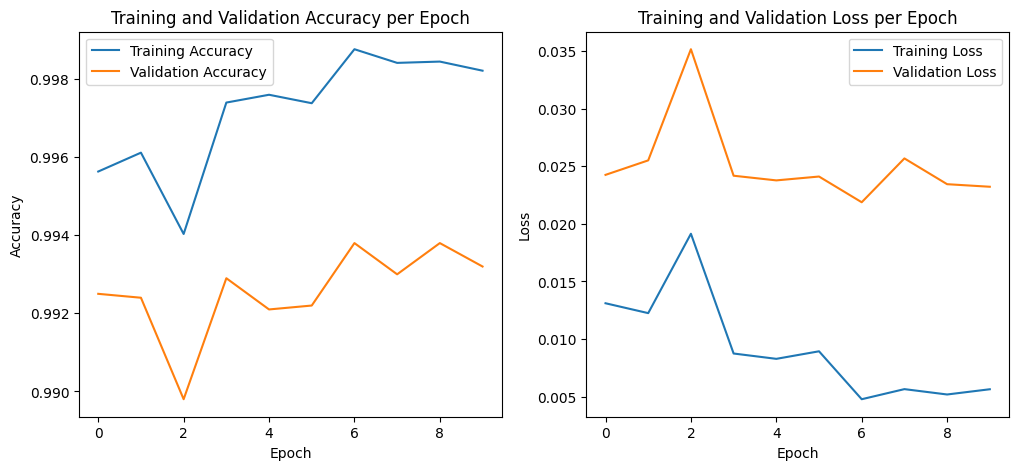

In [ ]:
# Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(train_accuracy_per_epoch, label='Training Accuracy')
plt.plot(val_accuracy_per_epoch, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy per Epoch')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(train_loss_per_epoch, label='Training Loss')
plt.plot(val_loss_per_epoch, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()

#plt.tight_layout()
plt.show()

#6. Model Testing

In [ ]:
# Evaluate model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.9932
Test Loss: 0.0232


###Creating and plot a confusion matrix.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


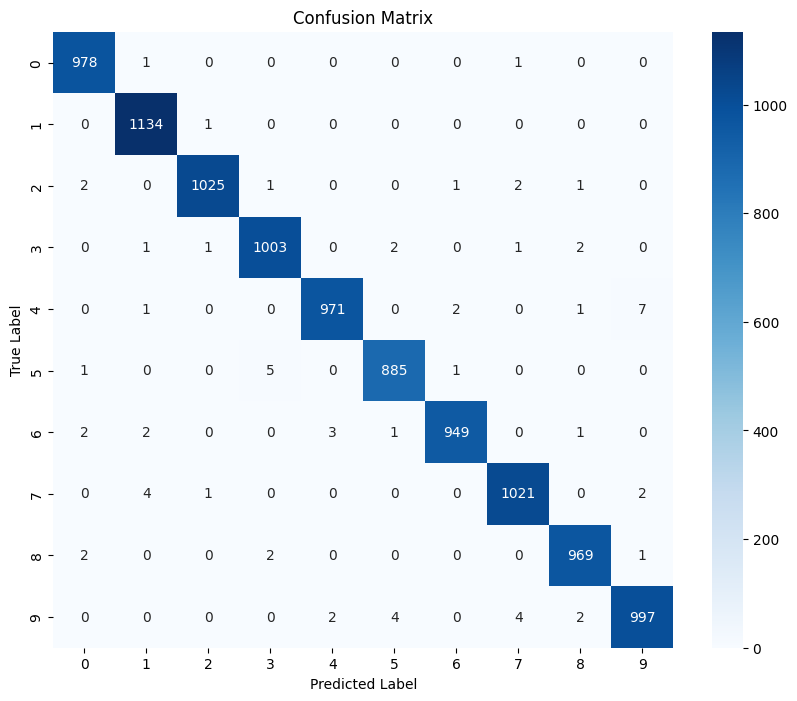

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict labels for the test set
y_pred = model.predict(x_test).argmax(axis=1)
y_true = y_test

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


###Generating and printing the classification report

In [ ]:
from sklearn.metrics import classification_report

# Generate classification report
class_report = classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)])
print("Classification Report:\n")
print(class_report)


Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      1.00      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



###Plotting Test Images with Predicted and True Labels

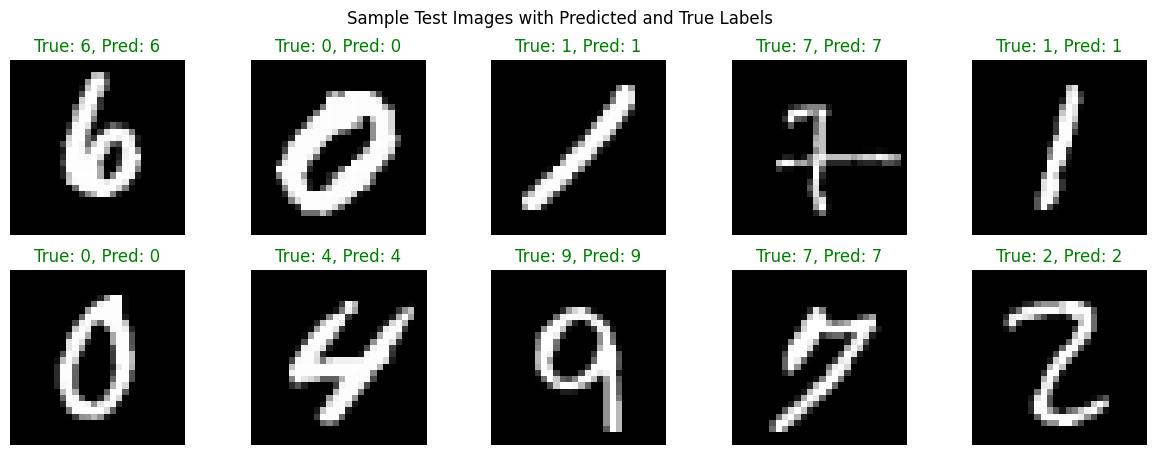

In [ ]:
# Plot a few test images with their predicted and true labels
# Number of images to display
num_images = 10
# Randomly select test images
indices = np.random.choice(range(len(x_test)), num_images, replace=False)

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    # Reshape the image for display
    image = x_test[idx].reshape(28, 28)
    true_label = y_true[idx]
    pred_label = y_pred[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {true_label}, Pred: {pred_label}", color="green" if true_label == pred_label else "red")
    plt.axis('off')

plt.suptitle("Sample Test Images with Predicted and True Labels")
plt.show()
